# Analysis of "saurabhshahane" Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import torch as pt
import re

In [2]:
df = pd.read_csv("../../Datasets/saurabhshahane/fake-news-classification/versions/77/WELFake_Dataset.csv")

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


## Dataset properties

In [ ]:
print(f"Dataset Shape: {df.shape}")

print("\nMissing values")
print(df.isnull().sum())

print("\nClass balance")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Dataset Shape: (72134, 4)

Missing values
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Class balance
label
1    37106
0    35028
Name: count, dtype: int64
label
1    0.514404
0    0.485596
Name: proportion, dtype: float64

Duplicate Rows: 0


/var/folders/dc/77k6d3lx0g383jd_j5xfbknm0000gn/T/ipykernel_77386/2260602632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


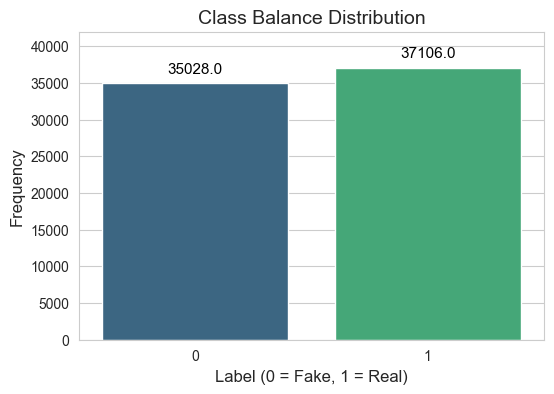

In [4]:
sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette='viridis')

plt.title('Class Balance Distribution', fontsize=14)
plt.xlabel('Label (0 = Fake, 1 = Real)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ylim(0, 42000)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

## Processing the dataset
- Combining title and text as some columns are missing one, also make integration with other datasets easier
- Drop unnecessary columns
- Clean combined textual data by removing non-unicode characters (emojis), URLs and phone numbers.
- Tokenise with BERT-tokeniser for future feature extraction with BERT

In [5]:
# Combine title and text
df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['combined_text'] = df['combined_text'].str.strip()

# After combining
print(df[['title', 'text', 'combined_text']].head(5))

print(f"\nMissing values in combined_text: {df['combined_text'].isnull().sum()}")
print(f"Empty strings in combined_text: {(df['combined_text'] == '').sum()}")

                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  \
0  No comment is expected from Barack Obama Membe...   
1     Did they post their votes for Hillary already?   
2   Now, most of the demonstrators gathered last ...   
3  A dozen politically active pastors came here f...   
4  The RS-28 Sarmat missile, dubbed Satan 2, will...   

                                       combined_text  
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...  
1     Did they post their votes for Hillary already?  
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...  
3  Bobby Jindal, raised Hindu, uses story of Chri...  
4  SATAN 2: Russia unvelis an image of its terrif..

In [6]:
df = df.drop(["title", "text", "Unnamed: 0"], axis=1)

df.head()

,label,combined_text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,1,Did they post their votes for Hillary already?
2,1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,1,SATAN 2: Russia unvelis an image of its terrif...


In [7]:
df = df[['combined_text', 'label']]
df.head()

,combined_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [14]:
# cleaning textual data

def clean_text(text):
    """
    Remove URLs, phone numbers, and non-unicode characters from text
    """
    if pd.isna(text):
        return ""
    
    # Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Matches: (123) 456-7890, 123-456-7890, 123.456.7890, 1234567890
    text = re.sub(r'\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}', '', text)
    
    # Remove non-ASCII/unicode characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning to combined_text
df['combined_text'] = df['combined_text'].apply(clean_text)

print("Sample cleaned text:")
print(df['combined_text'].head(3))
print(f"\nEmpty strings after cleaning: {(df['combined_text'] == '').sum()}")

Sample cleaned text:
0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1       Did they post their votes for Hillary already?
2    UNBELIEVABLE! OBAMAS ATTORNEY GENERAL SAYS MOS...
Name: combined_text, dtype: object

Empty strings after cleaning: 10


In [ ]:
df = df[df['combined_text'] != '']
print(f"After removing empty strings: {df.shape}")
print(f"\nEmpty strings after removal: {(df['combined_text'] == '').sum()}")

After removing empty strings: (72124, 3)


In [17]:
# using bert uncased, but cased should be used if case distinction is important
# should text further
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

df['tokenized'] = df['combined_text'].apply(
    lambda x: tokenizer.encode_plus(
        x,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
)

In [18]:
df.to_csv("processed_datasets/WELFake_Dataset_processed.csv")